# Carbon Footprints Prediction

# Problem Statement

### This project aims to develop an AI/ML-based predictive model that estimates the carbon footprint (kg CO₂) of an industry using operational features like energy consumption, fuel type, production capacity, and efficiency levels. Such a model will help organizations quantify, forecast, and minimize emissions, thereby supporting the goals of sustainable energy and efficiency.


# Importing libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# loading the dataset

In [4]:
df = pd.read_csv("dataset.csv")

In [5]:
df.head()

,Electricity_Usage_kWh,Fuel_Type,Production_Volume_Tons,Efficiency_Rating,Carbon_Footprint_kgCO2
0,16795,Natural Gas,1937,0.88,12004.1
1,1860,Natural Gas,3316,0.86,7038.8
2,39158,Natural Gas,716,0.82,21047.8
3,45732,Coal,4238,0.99,33471.0
4,12284,Renewables,721,0.95,6336.2


# Getting insights from the dataset

In [6]:
df.shape

(500, 5)

In [7]:
df.size

2500

In [8]:
df.dtypes

Electricity_Usage_kWh       int64
Fuel_Type                  object
Production_Volume_Tons      int64
Efficiency_Rating         float64
Carbon_Footprint_kgCO2    float64
dtype: object

In [9]:
df.info

<bound method DataFrame.info of      Electricity_Usage_kWh    Fuel_Type  Production_Volume_Tons  \
0                    16795  Natural Gas                    1937   
1                     1860  Natural Gas                    3316   
2                    39158  Natural Gas                     716   
3                    45732         Coal                    4238   
4                    12284   Renewables                     721   
..                     ...          ...                     ...   
495                  36247   Renewables                    1391   
496                  30222   Renewables                    8457   
497                  27211   Renewables                     388   
498                  38220         Coal                    5945   
499                  27646       Diesel                    2758   

     Efficiency_Rating  Carbon_Footprint_kgCO2  
0                 0.88                 12004.1  
1                 0.86                  7038.8  
2               

In [10]:
df.describe

<bound method NDFrame.describe of      Electricity_Usage_kWh    Fuel_Type  Production_Volume_Tons  \
0                    16795  Natural Gas                    1937   
1                     1860  Natural Gas                    3316   
2                    39158  Natural Gas                     716   
3                    45732         Coal                    4238   
4                    12284   Renewables                     721   
..                     ...          ...                     ...   
495                  36247   Renewables                    1391   
496                  30222   Renewables                    8457   
497                  27211   Renewables                     388   
498                  38220         Coal                    5945   
499                  27646       Diesel                    2758   

     Efficiency_Rating  Carbon_Footprint_kgCO2  
0                 0.88                 12004.1  
1                 0.86                  7038.8  
2             

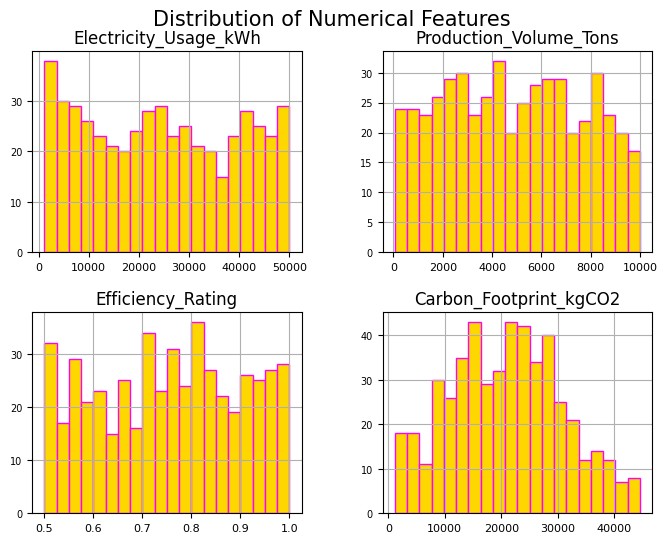

In [18]:
df.hist(figsize = (8, 6), bins = 20, xlabelsize = 8, ylabelsize = 7, color = 'gold', edgecolor = 'magenta')
plt.suptitle("Distribution of Numerical Features",fontsize = 15, y = 0.95)
plt.show()

# PREPROCESSING

# checking for null values

In [11]:
df.isnull()

,Electricity_Usage_kWh,Fuel_Type,Production_Volume_Tons,Efficiency_Rating,Carbon_Footprint_kgCO2
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
495,False,False,False,False,False
496,False,False,False,False,False
497,False,False,False,False,False
498,False,False,False,False,False


In [12]:
df.isnull().sum()

Electricity_Usage_kWh     0
Fuel_Type                 0
Production_Volume_Tons    0
Efficiency_Rating         0
Carbon_Footprint_kgCO2    0
dtype: int64

# defining the arrays

In [22]:
x = df.drop(['Carbon_Footprint_kgCO2'], axis = 1)
y = df['Carbon_Footprint_kgCO2']

In [24]:
x.head()

,Electricity_Usage_kWh,Fuel_Type,Production_Volume_Tons,Efficiency_Rating
0,16795,Natural Gas,1937,0.88
1,1860,Natural Gas,3316,0.86
2,39158,Natural Gas,716,0.82
3,45732,Coal,4238,0.99
4,12284,Renewables,721,0.95


In [25]:
y.head()

0    12004.1
1     7038.8
2    21047.8
3    33471.0
4     6336.2
Name: Carbon_Footprint_kgCO2, dtype: float64

In [26]:
print(df['Fuel_Type'].unique())

['Natural Gas' 'Coal' 'Renewables' 'Diesel']


In [28]:
df["Fuel_Type"] = df["Fuel_Type"].map({'Coal': 3, 'Diesel': 2, 'Natural Gas': 1, 'Renewables':0})

In [29]:
df.head()

,Electricity_Usage_kWh,Fuel_Type,Production_Volume_Tons,Efficiency_Rating,Carbon_Footprint_kgCO2
0,16795,1,1937,0.88,12004.1
1,1860,1,3316,0.86,7038.8
2,39158,1,716,0.82,21047.8
3,45732,3,4238,0.99,33471.0
4,12284,0,721,0.95,6336.2


# splitting the dataset

In [31]:
x_train, y_train, x_test, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [32]:
x_train

,Electricity_Usage_kWh,Fuel_Type,Production_Volume_Tons,Efficiency_Rating
249,9680,Natural Gas,5159,0.80
433,1876,Diesel,4275,0.97
19,18568,Renewables,7290,0.71
322,46525,Coal,7236,0.94
332,20738,Coal,6066,0.70
...,...,...,...,...
106,14986,Diesel,167,0.73
270,42976,Diesel,9574,0.87
348,19589,Diesel,6772,0.51
435,5142,Natural Gas,5991,0.58


In [33]:
y_train

,Electricity_Usage_kWh,Fuel_Type,Production_Volume_Tons,Efficiency_Rating
361,1699,Natural Gas,6662,0.89
73,38065,Coal,4256,0.56
374,37631,Coal,4227,0.83
155,44585,Coal,5465,0.94
104,40504,Renewables,6016,1.00
...,...,...,...,...
347,9208,Renewables,3350,0.79
86,9529,Coal,1783,0.92
75,34763,Coal,7993,0.90
438,8079,Natural Gas,4838,0.58


In [34]:
x_test

249    14326.2
433    10373.0
19     11032.0
322    41412.5
332    25834.0
        ...   
106     8130.4
270    42680.8
348    25182.9
435    13774.8
102     5110.8
Name: Carbon_Footprint_kgCO2, Length: 400, dtype: float64

In [35]:
y_test

361    12951.1
73     30112.5
374    29553.0
155    36015.0
104    21455.2
        ...   
347     5484.0
86      9302.0
75     37464.0
438    13167.9
15      3589.0
Name: Carbon_Footprint_kgCO2, Length: 100, dtype: float64